# RUL Prediction — Bidirectional LSTM
### CMAPSS FD001 Dataset

## Cell 1 — Imports

In [2]:
import pandas as pd
import numpy as np
import os
import datetime
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Bidirectional, LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import (
    TensorBoard, EarlyStopping, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam

print('TensorFlow:', tf.__version__)

TensorFlow: 2.19.0


## Cell 2 — Load the dataset

In [3]:

TRAIN_PATH = '/content/train_FD001.txt'
TEST_PATH  = '/content/test_FD001.txt'
RUL_PATH   = '/content/RUL_FD001.txt'   # ground-truth RUL for test engines


COLUMN_NAMES = [
    'engine_id', 'cycle',
    'op_setting_1', 'op_setting_2', 'op_setting_3',
    'sensor_1',  'sensor_2',  'sensor_3',  'sensor_4',  'sensor_5',
    'sensor_6',  'sensor_7',  'sensor_8',  'sensor_9',  'sensor_10',
    'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15',
    'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20',
    'sensor_21'
]

# Columns to drop:
#   sensor_20, sensor_21 : always NaN in FD001
#   op_setting_3, sensor_1, sensor_5, sensor_6,
#   sensor_10, sensor_16, sensor_18, sensor_19
#   op_setting_1, op_setting_2 : zero or near-zero variance
#   — constant values give the model nothing to learn from
DROP_COLS = [
    'sensor_20', 'sensor_21',        # always NaN
    'op_setting_3',                   # zero std
    'sensor_1',  'sensor_10',         # zero std
    'sensor_18', 'sensor_19',         # zero std
    'op_setting_1', 'op_setting_2',   # near-zero std
    'sensor_5',  'sensor_6',          # near-zero std
    'sensor_16',                      # near-zero std
]

train_data = pd.read_csv(TRAIN_PATH, header=None, names=COLUMN_NAMES, sep=r'\s+')

test_data  = pd.read_csv(TEST_PATH,  header=None, names=COLUMN_NAMES, sep=r'\s+')

# Drop uninformative columns from BOTH datasets
train_data = train_data.drop(columns=DROP_COLS)
test_data  = test_data.drop(columns=DROP_COLS)


# Load ground-truth RUL (one value per test engine)
true_rul = pd.read_csv(RUL_PATH, header=None, names=['true_rul'], sep=r'\s+')
true_rul['engine_id'] = np.arange(1, len(true_rul) + 1)

print(f'Train : {train_data.shape}  ({train_data["engine_id"].nunique()} engines)')
print(f'Test  : {test_data.shape}  ({test_data["engine_id"].nunique()} engines)')
print(f'RUL   : {true_rul.shape}')
print(f'\nFeatures kept: {[c for c in train_data.columns if c not in ["engine_id","cycle"]]}')

Train : (20631, 14)  (100 engines)
Test  : (13096, 14)  (100 engines)
RUL   : (100, 2)

Features kept: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17']


## Cell 3 — Compute RUL labels for training data

In [4]:
# Training: every engine ran to failure, so the last row = failure point.
# RUL = max_cycle_for_that_engine − current_cycle
# Clipped at MAX_RUL=125: cycles far from failure all say "engine is healthy".
# Keeping values like 300 swamps the loss and makes training unstable.

MAX_RUL = 125

train_data['RUL'] = (
    train_data.groupby('engine_id')['cycle'].transform('max')
    - train_data['cycle']
)
train_data['RUL'] = train_data['RUL'].clip(upper=MAX_RUL)

print('Train RUL stats:')
print(train_data['RUL'].describe())
print('\nEngine 1 — last 5 rows:')
print(train_data[train_data['engine_id']==1][['engine_id','cycle','RUL']].tail())

Train RUL stats:
count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

Engine 1 — last 5 rows:
     engine_id  cycle  RUL
187          1    188    4
188          1    189    3
189          1    190    2
190          1    191    1
191          1    192    0


## Cell 4 — Compute RUL labels for test data using RUL_FD001.txt

In [5]:
# The test file is a SNIPPET — each engine is cut off before failure.
# RUL_FD001.txt gives the TRUE remaining life at the cut-off point.
#
# Example: engine 1 has 31 rows in the test file.
#   RUL_FD001.txt says true RUL at cycle 31 = 112.
#   So:  cycle 31 → RUL = 112
#        cycle 30 → RUL = 113
#        cycle 1  → RUL = 142  (clipped to 125)
#
# Formula:  RUL_row = true_rul_at_cutoff + (last_cycle_in_snippet − current_cycle)

# How many cycles from the last recorded cycle
test_data['cycles_from_end'] = (
    test_data.groupby('engine_id')['cycle'].transform('max')
    - test_data['cycle']
)

# Merge in the ground-truth RUL at cut-off
test_data = test_data.merge(true_rul, on='engine_id', how='left')

# Full RUL per row
test_data['RUL'] = (test_data['true_rul'] + test_data['cycles_from_end']).clip(upper=MAX_RUL)

print('Test RUL stats (ground-truth based):')
print(test_data['RUL'].describe())

# Sanity check engine 1
e1 = test_data[test_data['engine_id']==1][['cycle','cycles_from_end','true_rul','RUL']]
print(f'\nEngine 1 ({len(e1)} rows). Last row RUL should equal true_rul=112:')
print(e1.tail())

Test RUL stats (ground-truth based):
count    13096.000000
mean       108.919823
std         27.580258
min          7.000000
25%        102.000000
50%        125.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

Engine 1 (31 rows). Last row RUL should equal true_rul=112:
    cycle  cycles_from_end  true_rul  RUL
26     27                4       112  116
27     28                3       112  115
28     29                2       112  114
29     30                1       112  113
30     31                0       112  112


## Cell 5 — Normalize RUL (y) to [0, 1]

In [6]:
# Fit the scaler ONLY on training RUL values.
# This maps 0 → 0.0  and  125 → 1.0
# We keep the scaler object to inverse-transform predictions back to cycles.

rul_scaler = MinMaxScaler(feature_range=(0, 1))
train_data['RUL_scaled'] = rul_scaler.fit_transform(train_data[['RUL']])
test_data['RUL_scaled']  = rul_scaler.transform(test_data[['RUL']])

print(f'Train RUL_scaled: {train_data["RUL_scaled"].min():.3f} – {train_data["RUL_scaled"].max():.3f}')
print(f'Test  RUL_scaled: {test_data["RUL_scaled"].min():.3f} – {test_data["RUL_scaled"].max():.3f}')

Train RUL_scaled: 0.000 – 1.000
Test  RUL_scaled: 0.056 – 1.000


## Cell 6 — Create sliding-window sequences

In [7]:
# 12 informative sensor/op-setting columns
FEATURE_COLS = [
    'sensor_2',  'sensor_3',  'sensor_4',  'sensor_7',
    'sensor_8',  'sensor_9',  'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17'
]
WINDOW_SIZE = 30

def create_sequences(data, feature_cols, rul_col='RUL_scaled', window_size=30):
    """
    Build sliding-window sequences per engine.
      X[i] : (window_size, n_features)  — sensor readings for this window
      y[i] : scalar                     — normalised RUL at the last timestep
    """
    X, y = [], []
    for eid in data['engine_id'].unique():
        eng  = data[data['engine_id'] == eid]
        feat = eng[feature_cols].values
        rul  = eng[rul_col].values
        for i in range(len(feat) - window_size):
            X.append(feat[i : i + window_size])
            y.append(rul[i + window_size])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_data, FEATURE_COLS, window_size=WINDOW_SIZE)
X_test,  y_test  = create_sequences(test_data,  FEATURE_COLS, window_size=WINDOW_SIZE)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}   y_test : {y_test.shape}')

X_train: (17631, 30, 12)  y_train: (17631,)
X_test : (10096, 30, 12)   y_test : (10096,)


## Cell 7 — Normalize features (X) to [0, 1]

In [8]:
# Fit the feature scaler ONLY on training windows to prevent data leakage.
# Reshape 3-D → 2-D for sklearn, scale, reshape back.

n_features = X_train.shape[-1]
feat_scaler = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = feat_scaler.fit_transform(
    X_train.reshape(-1, n_features)
).reshape(X_train.shape)

X_test_scaled = feat_scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(X_test.shape)

print(f'X_train_scaled: {X_train_scaled.min():.3f} – {X_train_scaled.max():.3f}')
print(f'X_test_scaled : {X_test_scaled.min():.3f} – {X_test_scaled.max():.3f}')
print(f'y_train       : {y_train.min():.3f} – {y_train.max():.3f}')
print(f'y_test        : {y_test.min():.3f} – {y_test.max():.3f}')

X_train_scaled: 0.000 – 1.000
X_test_scaled : -0.044 – 1.081
y_train       : 0.000 – 1.000
y_test        : 0.056 – 1.000


## Cell 8 — Build the Bidirectional LSTM model

In [9]:
def create_model(window_size, n_features, lr=1e-3):
    model = Sequential([
        Input(shape=(window_size, n_features)),

        # Layer 1: Bidirectional LSTM
        # Processes sequence both forward and backward.
        # return_sequences=True passes the full sequence to the next LSTM.
        Bidirectional(LSTM(100, return_sequences=True)),
        Dropout(0.3),
        BatchNormalization(),

        # Layer 2: LSTM refines temporal patterns
        LSTM(50, return_sequences=True),
        Dropout(0.3),
        BatchNormalization(),

        # Layer 3: final LSTM — collapses sequence to one vector
        LSTM(30),
        Dropout(0.3),
        BatchNormalization(),

        # Output: single value in [0,1] matching normalised RUL target
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mean_squared_error',
        metrics=['mae']
    )
    return model

model = create_model(WINDOW_SIZE, n_features)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 200)        │        90,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 200)        │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 30, 50)         │        50,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 50)         │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30)             │         9,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30)             │           120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,471 (591.68 KB)

 Trainable params: 150,911 (589.50 KB)

 Non-trainable params: 560 (2.19 KB)

## Cell 9 — Train the model

In [10]:
os.makedirs('../models', exist_ok=True)
os.makedirs('../logs/fit', exist_ok=True)

log_dir = '../logs/fit/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')

callbacks = [
    TensorBoard(log_dir=log_dir, histogram_freq=1),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '../models/best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - loss: 0.0537 - mae: 0.1755
Epoch 1: val_loss improved from None to 0.07164, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 36s 216ms/step - loss: 0.0380 - mae: 0.1496 - val_loss: 0.0716 - val_mae: 0.2376
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - loss: 0.0212 - mae: 0.1135
Epoch 2: val_loss improved from 0.07164 to 0.07017, saving model to ../models/best_model.keras

Epoch 2: finished saving model to ../models/best_model.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 24s 214ms/step - loss: 0.0203 - mae: 0.1103 - val_loss: 0.0702 - val_mae: 0.2238
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.0188 - mae: 0.1059
Epoch 3: val_loss improved from 0.07017 to 0.04826, saving model to ../models/best_model.keras

Epoch 3: finished saving model to ../models/best_model.keras
111/111 ━━━━━━━━━━━━━━━━━━━━ 22s 199ms/step - loss: 0.0178 - ma

## Cell 10 — Plot training history

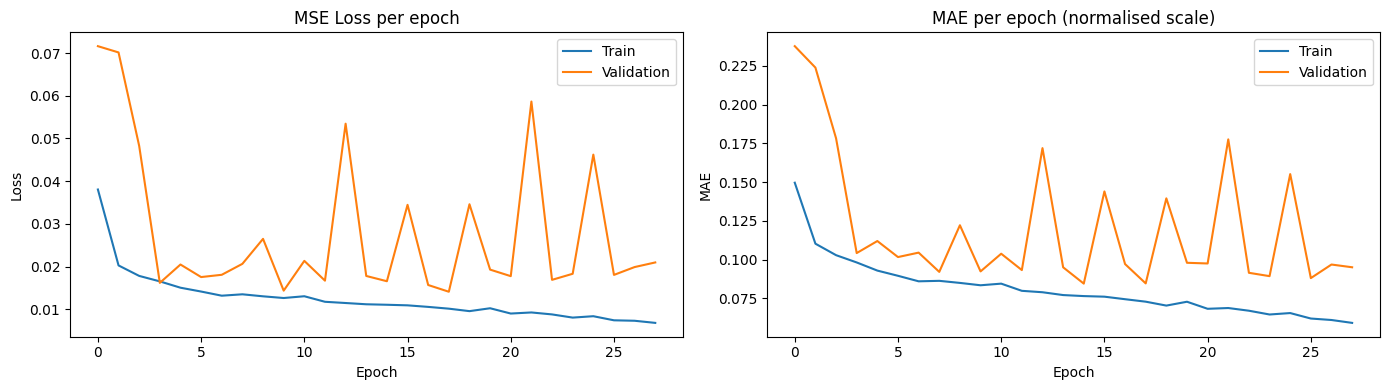

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_title('MSE Loss per epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train')
axes[1].plot(history.history['val_mae'], label='Validation')
axes[1].set_title('MAE per epoch (normalised scale)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

## Cell 11 — Evaluate (correct CMAPSS protocol)

For each of the 100 test engines:
- Take the **last 30 cycles** (final window)
- Predict ONE RUL value
- Compare against `RUL_FD001.txt` ground truth

This produces 100 predictions — one per engine — which is the standard benchmark.

In [12]:
def evaluate_per_engine(model, test_data, feature_cols, feat_scaler,
                        rul_scaler, true_rul_df, window_size=30):
    """
    Standard CMAPSS evaluation:
      - Extract the last `window_size` cycles per test engine
      - Make ONE prediction per engine
      - Compare to ground-truth from RUL_FD001.txt
    """
    n_features = len(feature_cols)
    records    = []

    for eid in sorted(test_data['engine_id'].unique()):
        eng  = test_data[test_data['engine_id'] == eid]
        feat = eng[feature_cols].values

        # Pad if the snippet is shorter than window_size (none in FD001, but safe)
        if len(feat) < window_size:
            pad  = np.tile(feat[0], (window_size - len(feat), 1))
            feat = np.vstack([pad, feat])

        # Last window: most recent 30 cycles
        window = feat[-window_size:]

        # Scale using the TRAINING scaler — no refit
        window_scaled = feat_scaler.transform(window).reshape(1, window_size, n_features)

        # Predict → inverse-transform → real cycle count
        pred_norm = model.predict(window_scaled, verbose=0)[0, 0]
        pred_rul  = float(rul_scaler.inverse_transform([[pred_norm]])[0, 0])

        # Ground-truth
        actual_rul = int(true_rul_df[true_rul_df['engine_id'] == eid]['true_rul'].values[0])

        records.append(dict(
            engine_id = eid,
            predicted = round(pred_rul, 1),
            actual    = actual_rul,
            error     = round(pred_rul - actual_rul, 1),
            abs_error = round(abs(pred_rul - actual_rul), 1)
        ))

    return pd.DataFrame(records)


results = evaluate_per_engine(
    model, test_data, FEATURE_COLS, feat_scaler, rul_scaler, true_rul, WINDOW_SIZE
)

rmse = np.sqrt((results['error'] ** 2).mean())
mae  = results['abs_error'].mean()
print(f'Test RMSE (cycles): {rmse:.2f}')
print(f'Test MAE  (cycles): {mae:.2f}')
print(f'\nPer-engine results:')
print(results.to_string(index=False))

Test RMSE (cycles): 17.99
Test MAE  (cycles): 13.53

Per-engine results:
 engine_id  predicted  actual  error  abs_error
         1      118.1     112    6.1        6.1
         2      124.7      98   26.7       26.7
         3       52.7      69  -16.3       16.3
         4       96.5      82   14.5       14.5
         5      112.5      91   21.5       21.5
         6      119.0      93   26.0       26.0
         7      119.1      91   28.1       28.1
         8      116.2      95   21.2       21.2
         9      119.8     111    8.8        8.8
        10       98.2      96    2.2        2.2
        11       83.7      97  -13.3       13.3
        12      102.5     124  -21.5       21.5
        13       80.5      95  -14.5       14.5
        14       87.1     107  -19.9       19.9
        15      105.8      83   22.8       22.8
        16      105.6      84   21.6       21.6
        17       54.0      50    4.0        4.0
        18       29.8      28    1.8        1.8
        19     

## Cell 12 — Visualise results

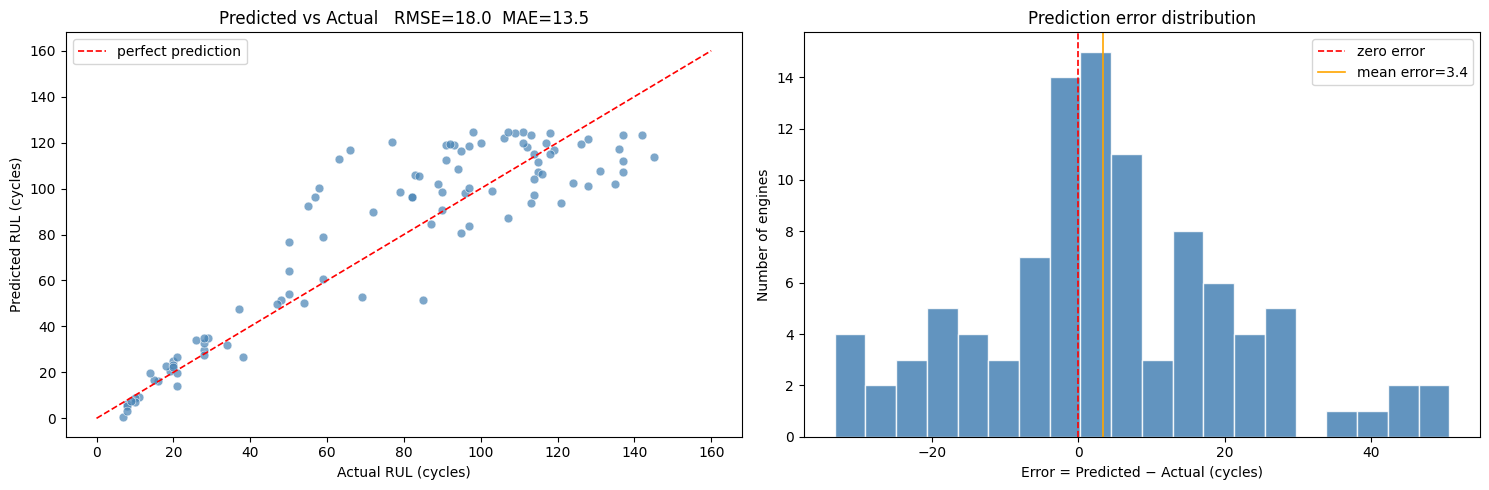

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# -- Scatter: predicted vs actual --
axes[0].scatter(results['actual'], results['predicted'],
                alpha=0.7, s=40, color='steelblue', edgecolors='white', linewidth=0.5)
lim = max(results[['actual','predicted']].max()) + 15
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.2, label='perfect prediction')
axes[0].set_xlabel('Actual RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')
axes[0].set_title(f'Predicted vs Actual   RMSE={rmse:.1f}  MAE={mae:.1f}')
axes[0].legend()

# -- Error histogram --
axes[1].hist(results['error'], bins=20,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2, label='zero error')
axes[1].axvline(results['error'].mean(), color='orange', linestyle='-',
                linewidth=1.2, label=f'mean error={results["error"].mean():.1f}')
axes[1].set_xlabel('Error = Predicted − Actual (cycles)')
axes[1].set_ylabel('Number of engines')
axes[1].set_title('Prediction error distribution')
axes[1].legend()

plt.tight_layout()
plt.show()